# AH溢价轮动策略 — 完整演示

策略逻辑：计算所有AH配对股的 H/A 溢价率，按溢价从高到低排序，持有前 N 只 A 股，等权配置，定期调仓。

H/A溢价率 = (H股价 × 汇率/100) / A股价 - 1，越高说明A股相对越便宜。

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from data.ah_fetcher import build_premium_panel, get_ah_pairs, get_fx_history
from strategies.ah_premium import AHPremiumStrategy

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 1. AH配对概况

In [2]:
pairs = get_ah_pairs()
print(f"AH配对总数: {len(pairs)}")
pairs.head(10)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

AH配对总数: 187


,a_code,h_code,name
0,601916,02016,浙商银行
1,601333,00525,广深铁路股份
2,601326,03369,秦港股份
3,601068,02068,中铝国际
4,600808,00323,马鞍山钢铁股份
5,002672,00895,东江环保
6,601375,01375,中州证券
7,601618,01618,中国中冶
8,000898,00347,鞍钢股份
9,601828,01528,红星美凯龙


## 2. 汇率数据

港币兑人民币中间价（CNY per 100 HKD）

汇率范围: 80.64 ~ 93.00


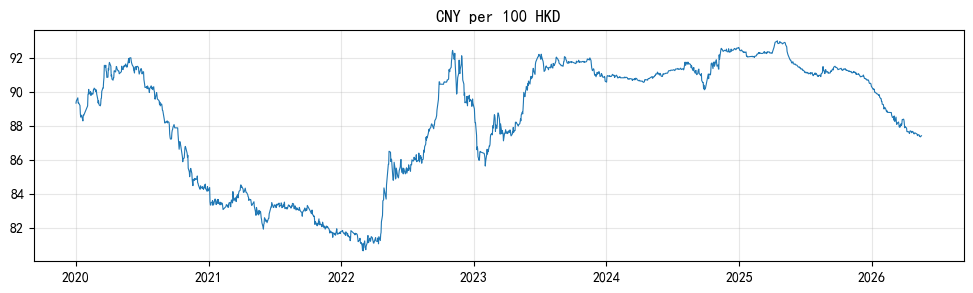

In [3]:
fx = get_fx_history('2020-01-01', '2026-05-18')
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(fx.index, fx.values, linewidth=0.8)
ax.set_title('CNY per 100 HKD')
ax.grid(True, alpha=0.3)
print(f"汇率范围: {fx.min():.2f} ~ {fx.max():.2f}")

## 3. 构建溢价率面板

首次运行会拉取所有AH股的A股和H股历史数据（约188对，数据缓存到 .cache/ 目录）。
后续运行直接从缓存读取，很快。

In [4]:
panel = build_premium_panel(start='2020-01-01', end='2026-05-18')

dates = panel.index.get_level_values('date').unique()
stocks = panel.index.get_level_values('stock').unique()
print(f"面板: {len(dates)} 个交易日 × {len(stocks)} 只股票")
print(f"日期范围: {dates[0].date()} ~ {dates[-1].date()}")

  0%|          | 0/10 [00:00<?, ?it/s]

  [30/187] 已加载 001389 广合科技 (36 条)
  [60/187] 已加载 000338 潍柴动力 (1494 条)
  [90/187] 已加载 601995 中金公司 (1281 条)
  [120/187] 已加载 601607 上海医药 (1494 条)
  [150/187] 已加载 601288 农业银行 (1494 条)
  [180/187] 已加载 601818 中国光大银行 (1494 条)

面板构建完成: 1493 个交易日 × 187 只股票
面板: 1493 个交易日 × 187 只股票
日期范围: 2020-01-02 ~ 2026-05-18


### 3.1 溢价率快照 — 最新交易日排名

In [5]:
latest = panel.loc[dates[-1]].copy()
latest = latest.sort_values('premium', ascending=False)

print(f"{dates[-1].date()} 溢价率排名")
print(f"{'排名':<5} {'代码':<8} {'名称':<12} {'A收盘':<10} {'H收盘':<10} {'溢价率':<8}")
print('-' * 55)
for i, (code, row) in enumerate(latest.iterrows()):
    if i >= 15:
        break
    print(f"{i+1:<5} {code:<8} {row.get('name', '?'):<12} {row['a_close']:<10.2f} {row['h_close']:<10.2f} {row['premium']:<8.1%}")

2026-05-18 溢价率排名
排名    代码       名称           A收盘        H收盘        溢价率     
-------------------------------------------------------
1     688008   澜起科技         247.99     440.80     55.4%   
2     300750   宁德时代         417.23     674.50     41.3%   
3     603986   兆易创新         400.00     588.00     28.5%   
4     600036   招商银行         37.47      46.58      8.7%    
5     603259   药明康德         102.05     125.80     7.8%    
6     600276   恒瑞医药         52.43      63.20      5.4%    
7     000338   潍柴动力         33.30      40.12      5.3%    
8     605499   东鹏饮料         142.20     165.60     1.8%    
9     601318   中国平安         54.89      61.85      -1.5%   
10    600031   三一重工         19.39      21.84      -1.5%   
11    000333   美的集团         82.83      91.70      -3.2%   
12    601899   紫金矿业         31.30      34.42      -3.9%   
13    601328   交通银行         6.66       7.25       -4.8%   
14    300476   胜宏科技         346.20     368.80     -6.9%   
15    600660   福耀玻璃         55.41      58.

## 4. 运行策略回测

In [6]:
# 策略参数
TOP_N = 10         # 持仓数量
REBALANCE = 20     # 调仓频率（交易日）

strategy = AHPremiumStrategy(top_n=TOP_N, rebalance_freq=REBALANCE)
result = strategy.run(panel=panel)

print(f"策略: {strategy.name}")
for k, v in result['metrics'].items():
    print(f"  {k}: {v}")

策略: AH溢价轮动(top10, 20日调仓)
  累计收益率: 140.59%
  年化收益率: 15.97%
  年化波动率: 22.29%
  夏普比率: 0.64
  最大回撤: -33.70%
  基准年化收益: 9.04%
  超额收益: 6.93%
  日胜率: 51.64%


## 5. 调仓明细

In [7]:
name_map = {}
for (dt, code), row in panel.iterrows():
    name_map[code] = row.get('name', '')
name_map = {k: v for k, v in name_map.items() if v}

def fmt(s):
    if not s: return '—'
    return ', '.join(name_map.get(c, c) for c in s.split(','))

hl = result['holdings_log']
print(f"{'日期':<12} {'调入':<45} {'调出':<45}")
print('-'*12 + ' ' + '-'*45 + ' ' + '-'*45)
for _, log in hl.iterrows():
    dt = str(log['date'])[:10]
    print(f"{dt:<12} {fmt(log['buy']):<45} {fmt(log['sell']):<45}")

日期           调入                                            调出                                           
------------ --------------------------------------------- ---------------------------------------------
2020-01-02   万科企业, 潍柴动力, 青岛银行, 招商银行, 海螺水泥, 青岛啤酒股份, 福耀玻璃, 马鞍山钢铁股份, 中国平安, 药明康德 —                                            
2020-02-07   康龙化成                                          青岛啤酒股份                                       
2020-03-06   中联重科, 青岛啤酒股份, 工商银行                            青岛银行, 康龙化成, 福耀玻璃                             
2020-04-03   康龙化成, 民生银行                                    中联重科, 青岛啤酒股份                                 
2020-05-12   交通银行, 建设银行                                    民生银行, 马鞍山钢铁股份                                
2020-06-09   青岛银行, 邮储银行                                    康龙化成, 建设银行                                   
2020-07-10   福耀玻璃, 建设银行                                    交通银行, 工商银行                                   
2020-08-07   比亚迪股份, 泰格医药, 浙商银行       

## 6. 可视化

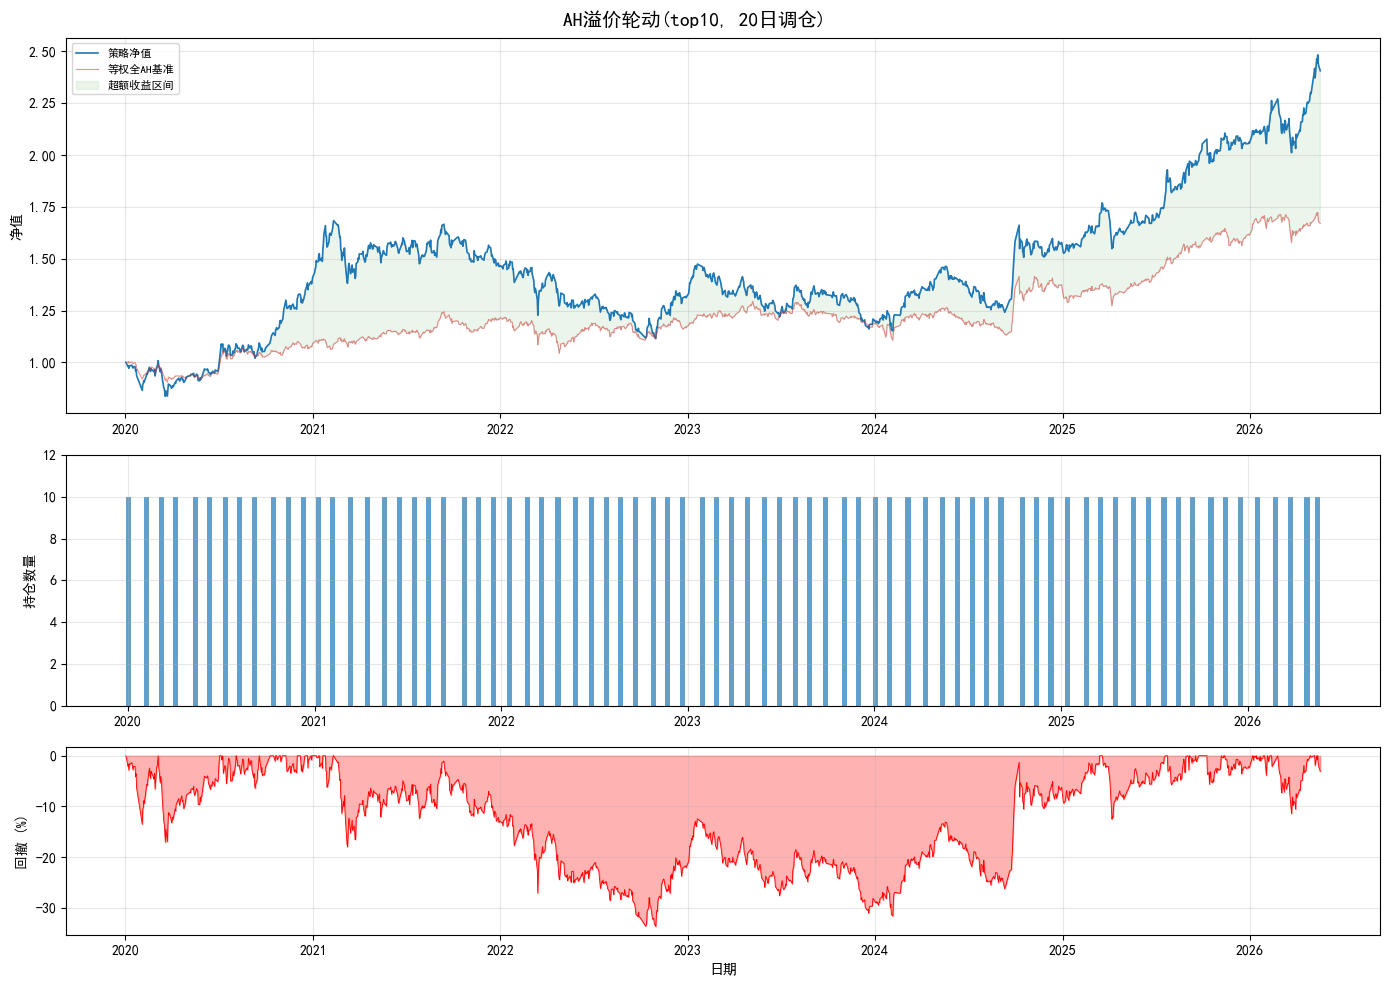

In [8]:
equity = result['equity']
benchmark = result['benchmark_equity']
holdings_log = result['holdings_log']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 2, 1.5]})
fig.suptitle(strategy.name, fontsize=14, fontweight='bold')

# 净值曲线
ax1 = axes[0]
ax1.plot(equity.index, equity.values, label='策略净值', color='#1f77b4', linewidth=1.2)
ax1.plot(benchmark.index, benchmark.values, label='等权全AH基准', color='#d62728', alpha=0.5, linewidth=0.8)
ax1.fill_between(equity.index, equity.values, benchmark.values,
                 where=equity.values >= benchmark.values,
                 color='green', alpha=0.08, label='超额收益区间')
ax1.set_ylabel('净值')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 持仓数量
ax2 = axes[1]
ax2.bar(holdings_log['date'], holdings_log['n_holdings'],
        width=max(1, 10), color='#1f77b4', alpha=0.7)
ax2.set_ylabel('持仓数量')
ax2.set_ylim(0, max(holdings_log['n_holdings'].max() + 2, 12))
ax2.grid(True, alpha=0.3)

# 回撤
ax3 = axes[2]
peak = equity.cummax()
drawdown = (equity - peak) / peak * 100
ax3.fill_between(equity.index, 0, drawdown, color='red', alpha=0.3)
ax3.plot(equity.index, drawdown, color='red', linewidth=0.6)
ax3.set_ylabel('回撤 (%)')
ax3.set_xlabel('日期')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 参数敏感性分析

遍历不同持仓数量和调仓频率，观察对夏普比率的影响。

In [ ]:
results = []
for top in [3, 5, 10, 15, 20]:
    for freq in [10, 20, 40, 60]:
        s = AHPremiumStrategy(top_n=top, rebalance_freq=freq)
        r = s.run(panel=panel)
        results.append({'top_n': top, 'rebalance_freq': freq, **r['metrics']})

# param_df = pd.DataFrame(results)
# param_df['夏普比率'] = param_df['夏普比率'].astype(float)

# # 透视表
# pivot = param_df.pivot_table(values='夏普比率', index='top_n', columns='rebalance_freq')
# pivot

rebalance_freq,10,20,40,60
top_n,,,,
3,0.53,0.50,0.45,0.34
5,0.70,0.75,0.56,0.56
10,0.61,0.64,0.65,0.65
15,0.76,0.79,0.71,0.85
20,0.89,0.84,0.73,0.80


In [11]:
param_df = pd.DataFrame(results)
param_df['年化收益率'] = param_df['年化收益率'].str.rstrip('%').astype(float)

# 透视表
pivot = param_df.pivot_table(values='年化收益率', index='top_n', columns='rebalance_freq')
pivot

rebalance_freq,10,20,40,60
top_n,,,,
3,14.85,13.83,12.10,8.88
5,18.85,20.35,14.75,14.60
10,15.19,15.97,16.03,16.03
15,17.81,18.27,16.38,19.74
20,19.80,18.52,15.95,17.64


---
## 8. 策略扩展思路

- **双向交易**: 溢价率极高时做多A股，溢价率极低时做多H股
- **动态仓位**: 根据溢价率偏离历史均值的程度调整仓位
- **行业中性**: 按行业分组，每组内选溢价最高的N只
- **止损机制**: 单只股票最大回撤超过阈值时强制卖出
- **加入基本面因子**: 结合PE/PB等估值指标的多因子轮动